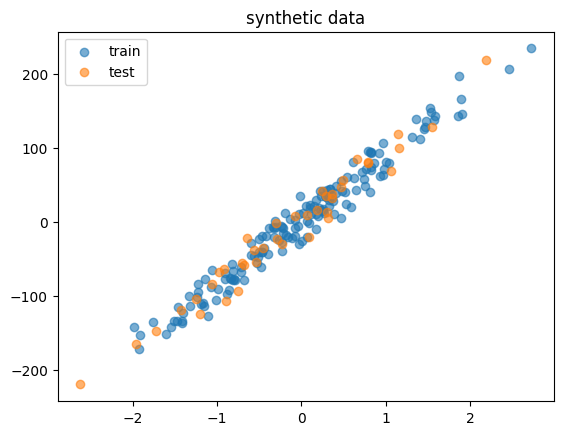

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# generate synthetic data
X, y = make_regression(n_samples=200, n_features=1,
                       noise=15, random_state=42)
y = y.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# quick look
plt.scatter(X_train, y_train, alpha=0.6, label="train")
plt.scatter(X_test,  y_test,  alpha=0.6, label="test")
plt.legend(); plt.title("synthetic data"); plt.show()

In [2]:
# add bias column of 1s so θ includes θ₀
X_b = np.c_[np.ones((len(X_train), 1)), X_train]

# normal equation: θ = (XᵀX)⁻¹ Xᵀy  — write this on paper first!
theta_normal = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_train

print("Normal Eq  → θ₀ (bias):", round(theta_normal[0][0], 4),
      " θ₁:", round(theta_normal[1][0], 4))

# mse helper
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

X_test_b = np.c_[np.ones((len(X_test), 1)), X_test]
preds_normal = X_test_b @ theta_normal
print("MSE (normal eq):", round(mse(y_test, preds_normal), 4))

Normal Eq  → θ₀ (bias): 1.8346  θ₁: 86.818
MSE (normal eq): 246.1218


Gradient D → θ₀: 1.8346  θ₁: 86.818


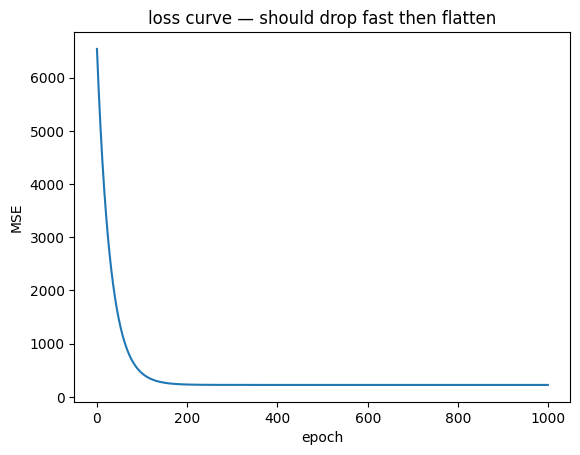

In [ ]:
# hyperparameters — try changing these!
eta        = 0.01   # learning rate
n_epochs   = 1000
m          = len(X_train)

# random init
np.random.seed(42)
theta_gd = np.random.randn(2, 1)

loss_history = []

for epoch in range(n_epochs):
    preds     = X_b @ theta_gd
    error     = preds - y_train
    gradients = (2/m) * X_b.T @ error   # ∂MSE/∂θ
    theta_gd  = theta_gd - eta * gradients 
    loss_history.append(mse(y_train, preds))

print("Gradient D → θ₀:", round(theta_gd[0][0], 4),
      " θ₁:", round(theta_gd[1][0], 4))

# plot convergence
plt.plot(loss_history)
plt.xlabel("epoch"); plt.ylabel("MSE")
plt.title("loss curve — should drop fast then flatten"); plt.show()

Sklearn    → θ₀: 1.8346  θ₁: 86.818
MSE (sklearn)  : 246.1218


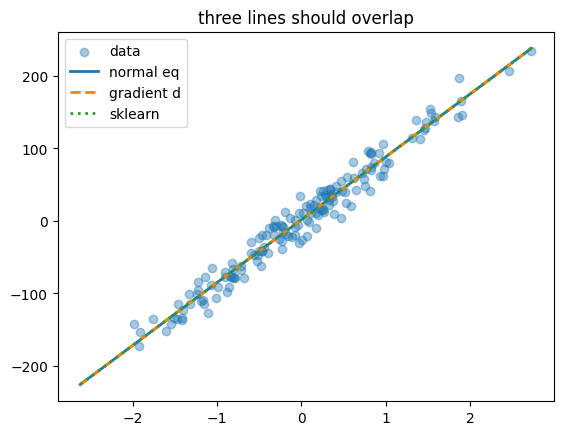

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Sklearn    → θ₀:", round(model.intercept_[0], 4),
      " θ₁:", round(model.coef_[0][0], 4))

preds_sk = model.predict(X_test)
print("MSE (sklearn)  :", round(mse(y_test, preds_sk.reshape(-1,1)), 4))

# ── all three θ values should be very close ──

# overlay all three fits
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
x_line_b = np.c_[np.ones((100, 1)), x_line]

plt.scatter(X_train, y_train, alpha=0.4, label="data")
plt.plot(x_line, x_line_b @ theta_normal, label="normal eq",  lw=2)
plt.plot(x_line, x_line_b @ theta_gd,     label="gradient d",  lw=2, linestyle="--")
plt.plot(x_line, model.predict(x_line),   label="sklearn",     lw=2, linestyle=":")
plt.legend(); plt.title("three lines should overlap"); plt.show()

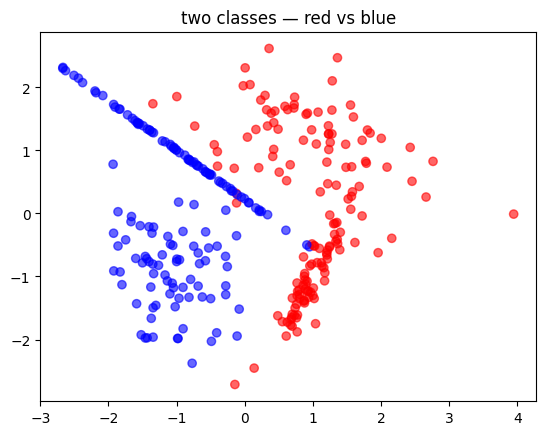

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# binary classification, 2 features so we can plot decision boundary
X, y = make_classification(n_samples=300, n_features=2,
                            n_redundant=0, n_informative=2,
                            random_state=42)
y = y.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# quick look
plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap="bwr", alpha=0.6)
plt.title("two classes — red vs blue"); plt.show()

In [2]:
# write this from memory — σ(z) = 1 / (1 + e^(-z))
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# sanity check: sigmoid(0) must be 0.5, sigmoid(100) ≈ 1, sigmoid(-100) ≈ 0
print(sigmoid(0), sigmoid(100), sigmoid(-100))

0.5 1.0 3.7200759760208356e-44


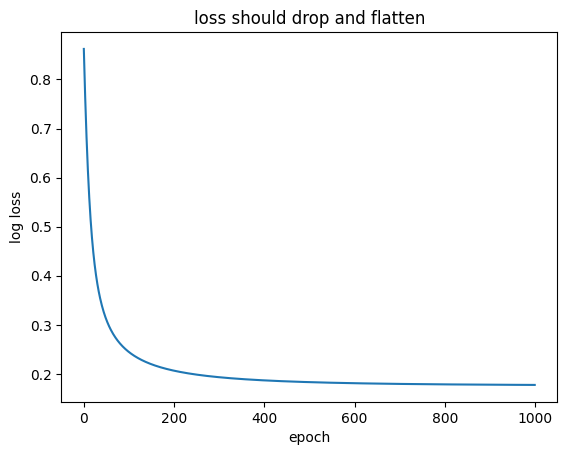

GD accuracy: 0.9
theta: [0.04234512 3.76230072 0.57889864]


In [3]:
# add bias column
X_b = np.c_[np.ones((len(X_train), 1)), X_train]
m   = len(X_train)

# hyperparameters
eta      = 0.1
n_epochs = 1000

# random init
np.random.seed(42)
theta = np.random.randn(3, 1)  # 3 = bias + 2 features

loss_history = []

def log_loss(y_true, p_hat):
    # clip to avoid log(0)
    p_hat = np.clip(p_hat, 1e-7, 1 - 1e-7)
    return -np.mean(y_true * np.log(p_hat) + (1 - y_true) * np.log(1 - p_hat))

for epoch in range(n_epochs):
    z      = X_b @ theta                # linear combination
    p_hat  = sigmoid(z)               # squeeze to probability
    error  = p_hat - y_train            # (p̂ - y) — from derivation above
    grad   = (1/m) * X_b.T @ error    # ∇J(θ) — identical form to linear!
    theta  = theta - eta * grad
    loss_history.append(log_loss(y_train, p_hat))

plt.plot(loss_history)
plt.xlabel("epoch"); plt.ylabel("log loss")
plt.title("loss should drop and flatten"); plt.show()

# accuracy on test set
X_test_b = np.c_[np.ones((len(X_test), 1)), X_test]
p_test   = sigmoid(X_test_b @ theta)
preds_gd = (p_test >= 0.5).astype(int)
print("GD accuracy:", round(accuracy_score(y_test, preds_gd), 4))
print("theta:", theta.ravel())

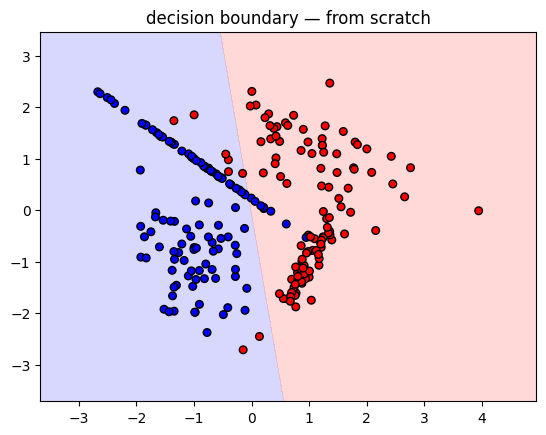

In [4]:
def plot_boundary(X, y, theta, title):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid   = np.c_[np.ones(xx.ravel().shape), xx.ravel(), yy.ravel()]
    probs  = sigmoid(grid @ theta).reshape(xx.shape)
    plt.contourf(xx, yy, probs, levels=[0, 0.5, 1], alpha=0.3, cmap="bwr")
    plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap="bwr", edgecolors="k", s=30)
    plt.title(title); plt.show()

plot_boundary(X_train, y_train, theta, "decision boundary — from scratch")

###starting decision trees###

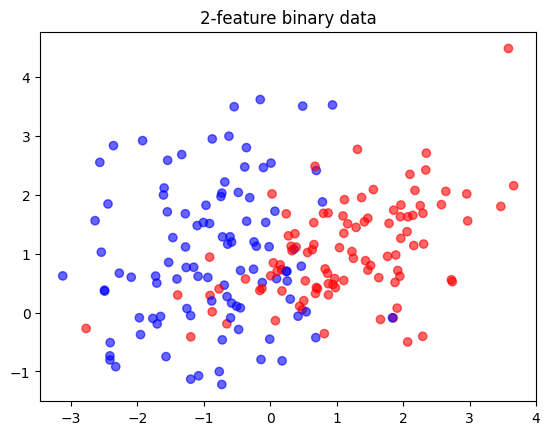

In [1]:
##decision trees##
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

X, y = make_classification(n_samples=200, n_features=2,
                           n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", alpha=0.6)
plt.title("2-feature binary data"); plt.show()

In [3]:
def entropy(y):
    # H = -sum(p_k * log2(p_k))
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum(probs * np.log2(probs + 1e-9))  # 1e-9 avoids log(0)

def information_gain(y_parent, y_left, y_right):
    # IG = H(parent) - weighted avg H(children)
    n  = len(y_parent)
    nl = len(y_left)
    nr = len(y_right)
    return (entropy(y_parent)
            - (nl/n) * entropy(y_left)
            - (nr/n) * entropy(y_right))

# ── verify your paper calculations ──
y_pure_left  = np.array([0,0,0,0,0])
y_pure_right = np.array([1,1,1,1,1])
y_parent     = np.concatenate([y_pure_left, y_pure_right])

print("H(parent 50/50)    :", round(entropy(y_parent), 4))       # → 1.0
print("IG (perfect split) :", round(information_gain(
    y_parent, y_pure_left, y_pure_right), 4))                      # → 1.0

y_useless_left  = np.array([0,0,0,1,1,1])
y_useless_right = np.array([0,0,1,1])
print("IG (useless split) :", round(information_gain(
    y_parent, y_useless_left, y_useless_right), 4))               # → ~0.0

H(parent 50/50)    : 1.0
IG (perfect split) : 1.0
IG (useless split) : 0.0


In [ ]:
def best_split(X, y):
    # try every feature and threshold, return best (feature, threshold)
    y = y.ravel()
    best_ig, best_feat, best_thresh = -1, None, None
    for feat in range(X.shape[1]):
        thresholds = np.unique(X[:, feat])
        for t in thresholds:
            left  = y[X[:, feat] <= t]
            right = y[X[:, feat] >  t]
            if len(left) == 0 or len(right) == 0:
                continue
            ig = information_gain(y, left, right)
            if ig > best_ig:
                best_ig, best_feat, best_thresh = ig, feat, t
    return best_feat, best_thresh

def build_tree(X, y, depth=0, max_depth=10):
    y = y.ravel()
    # base cases: pure node or max depth reached
    if len(np.unique(y)) == 1 or depth == max_depth:
        return {"leaf": True, "class": int(np.bincount(y).argmax())}

    feat, thresh = best_split(X, y)
    if feat is None:
        return {"leaf": True, "class": int(np.bincount(y).argmax())}

    mask = X[:, feat] <= thresh
    return {
        "leaf"     : False,
        "feature"  : feat,
        "threshold": thresh,
        "left"     : build_tree(X[mask],  y[mask],  depth+1, max_depth),
        "right"    : build_tree(X[~mask], y[~mask], depth+1, max_depth),
    }

def predict_one(node, x):
    if node["leaf"]:
        return node["class"]
    if x[node["feature"]] <= node["threshold"]:
        return predict_one(node["left"],  x)
    return predict_one(node["right"], x)

tree = build_tree(X_train, y_train, max_depth=10)
preds_scratch = np.array([predict_one(tree, x) for x in X_test])
print("Accuracy (scratch):", round(accuracy_score(y_test, preds_scratch), 4))

NameError: name 'X_train' is not defined

Accuracy (sklearn) : 0.85


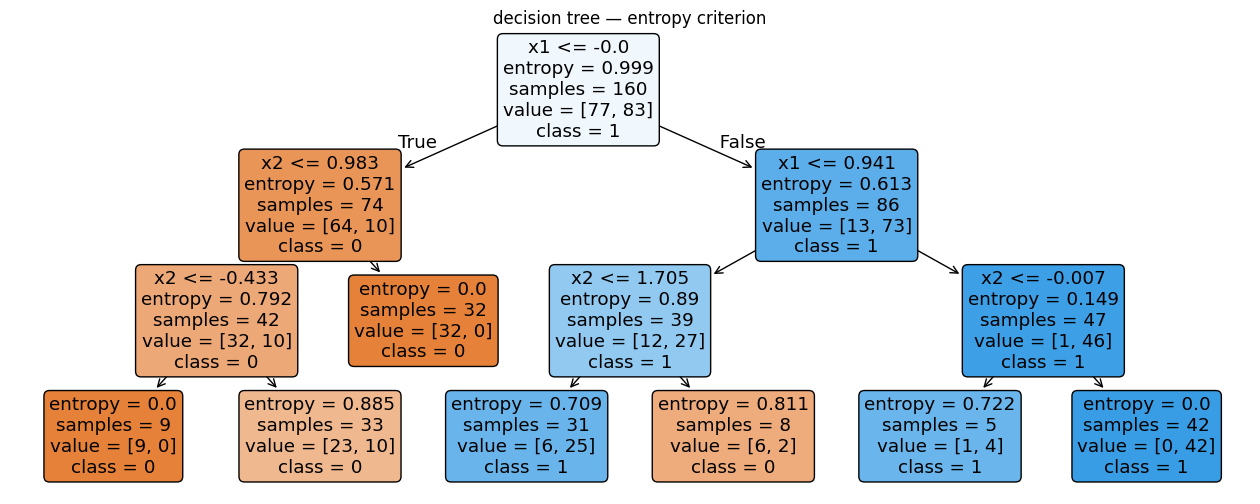

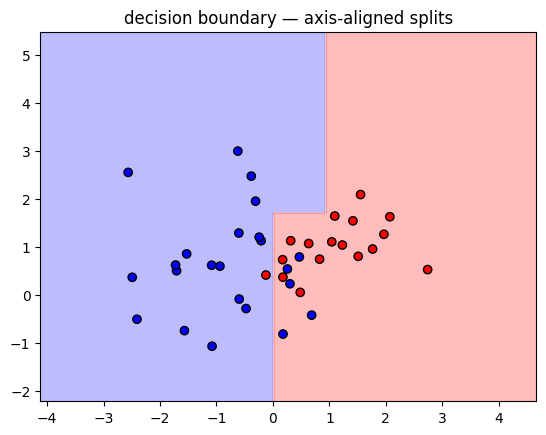

In [ ]:
model = DecisionTreeClassifier(max_depth=10, criterion="entropy", random_state=42)
model.fit(X_train, y_train)
print("Accuracy (sklearn) :", round(accuracy_score(y_test, model.predict(X_test)), 4))

# ── visualize the actual tree structure ──
plt.figure(figsize=(16, 6))
plot_tree(model, filled=True, feature_names=["x1", "x2"],
          class_names=["0", "1"], impurity=True, rounded=True)
plt.title("decision tree — entropy criterion"); plt.show()

# ── plot decision boundary ──
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap="bwr")
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap="bwr", edgecolors="k")
plt.title("decision boundary — axis-aligned splits"); plt.show()